In [1]:
# Importing package

import re
from collections import Counter
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
import arabic_reshaper
from bidi.algorithm import get_display
from matplotlib.font_manager import FontProperties
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report,
    roc_curve
)
import pickle

In [2]:
# Opening CSV file

df = pd.read_csv(r'A:\Projects\SentimentAnalyze\snappfood_comments.csv', encoding='utf-8', on_bad_lines="skip")
df.head(5)


,code,customerId,text,rating,date,feeling
0,p86152,130744,نون سیر خشک تلخ ،پیترا مخلوط بسیار بسیار بی کیفیت,2,۱۴۰۴/۱۲/۲۸,SAD
1,p86152,36864388,چیز برگر ارسال نشد,2,۱۴۰۴/۱۲/۲۸,SAD
2,p86152,4372759,حتی در زمان جنگ و ماه رمضان هم کیفیت خوب بود,10,۱۴۰۴/۱۲/۲۷,HAPPY
3,p86152,6947568,عالی بود و به موقع رسید,10,۱۴۰۴/۱۲/۲۶,HAPPY
4,p86152,19051568,مغایرت در سفارش و عدم توجه به توضیحات همراه با...,2,۱۴۰۴/۱۲/۲۶,SAD


In [3]:
df['rating'].value_counts()


rating
10    41691
8      4549
6      2344
0      1874
2      1769
4      1011
5        16
3         4
Name: count, dtype: int64

In [4]:
# Keeping samples with a valid label

df['rating'] = df['rating'] / 2
df['rating'] = df['rating'].astype(int)
df = df[df['rating'] != 0]
df['rating'].value_counts()

rating
5    41691
4     4549
3     2344
1     1773
2     1027
Name: count, dtype: int64

In [5]:
# Keeping valueable comments

df['text_length'] = df['text'].str.len()
df = df[df['text_length'] >= 5]
df = df.drop(columns=['text_length'])

In [6]:
# Cleaning noisy text

def clean_persian_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\S+', '', text)
    text = text.replace("\u064a", "\u06cc").replace("\u0643", "\u06a9")
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)
    
    # removing inert stopwords
    stopwords = {'\u0648', '\u06a9\u0647', '\u0627\u0632', '\u0628\u0647', '\u062f\u0631', '\u0628\u0627', '\u0627\u06cc\u0646', '\u0628\u0631\u0627\u06cc', '\u0631\u0648', '\u062a\u0627'}
    text = ' '.join([w for w in text.split() if w not in stopwords])
    
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning dataset in progress ...")
df['cleaned_text'] = df['text'].apply(clean_persian_text) #applying operatio to all values

# NEW: Dropping rows that became completely empty after cleaning
df = df[df['cleaned_text'].str.strip() != '']
df = df.reset_index(drop=True)

print("Its done! ")

Cleaning dataset in progress ...
Its done! 


In [7]:
# Creating vocabulary

all_words = []
for text in df['cleaned_text']:
    all_words.extend(text.split()) #text -> list of word -> add to all_words

word_counts = Counter(all_words) #output a dic: (word (key): cout (value))
min_freq = 2 #words whould have atleast 2 characters to be added
vocab = {"<PAD>": 0, "<UNK>": 1} #helping tokens for padding and unknowns

idx = 2
for word, count in word_counts.items():
    if count >= min_freq and len(word) >= 2:
        vocab[word] = idx
        idx += 1

VOCAB_SIZE = len(vocab)
print(f"Vocabulary has been made succesfully with VOCAB_SIZE of {VOCAB_SIZE}.")

Vocabulary has been made succesfully with VOCAB_SIZE of 6689.


In [8]:
# Tokenization & Padding

MAX_SEQ_LEN = 50

def tokenize_and_pad(text, vocab, max_len):
    words = text.split()
    # replacing unknown word
    tokens = [vocab.get(word, vocab["<UNK>"]) for word in words]
    
    # padding
    if len(tokens) < max_len:
        tokens = tokens + [vocab["<PAD>"]] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
    return tokens

print("Tokenizing...")
X_all = np.array([tokenize_and_pad(t, vocab, MAX_SEQ_LEN) for t in df['cleaned_text']])#111111111
y_all = df['rating'].values - 1 # labels from 1 to 5
print("Its done!")

Tokenizing...
Its done!


In [9]:
# Splitting dataset with balanced disterbution of labels

X_train, X_valtest, y_train, y_valtest = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all
)

X_val, X_test, y_val, y_test = train_test_split(
    X_valtest, y_valtest, test_size=0.50, random_state=42, stratify=y_valtest
)


In [10]:
# Dataset and Data loader

class SnappFoodDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_dataset = SnappFoodDataset(X_train, y_train)
val_dataset = SnappFoodDataset(X_val, y_val)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples count: {len(train_dataset)} | Validation samples count {len(val_dataset)}")

Training samples count: 38679 | Validation samples count 4835


In [11]:
# Defining Expert and Feed Forward

class Expert(nn.Module):
    def __init__(self, d_model, d_hidden, dropout_rate=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_model),
            nn.Dropout(dropout_rate)
        )
    def forward(self, x):
        return self.net(x)

In [12]:
# Defining MoE Layer

class SparseMoELayer(nn.Module):
    def __init__(self, d_model, d_hidden, num_experts, top_k=1, aux_loss_coef=0.01):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.aux_loss_coef = aux_loss_coef
        
        self.experts = nn.ModuleList([Expert(d_model, d_hidden) for _ in range(num_experts)])
        self.router = nn.Linear(d_model, num_experts)
        
        # defining variable for last routing situation (for visualization)
        self.last_routing_weights = None
        self.current_aux_loss = 0.0

    def forward(self, x, return_weights=False, mask=None):
        # x shape: [batch_size, seq_len, d_model]
        B, S, D = x.shape
        x_flat = x.view(-1, D)  # [B*S, D]
        
        # calculating logits and routor probabilities
        router_logits = self.router(x_flat)  # [B*S, num_experts]
        routing_weights = F.softmax(router_logits, dim=-1)  # [B*S, num_experts]
        
        # saving wights for visualization
        self.last_routing_weights = routing_weights.detach().view(B, S, self.num_experts)
        
        # selecting K-Top experts
        topk_weights, topk_indices = torch.topk(routing_weights, self.top_k, dim=-1)
        
        # renormalizing selected weights
        topk_weights = topk_weights / (topk_weights.sum(dim=-1, keepdim=True) + 1e-6)
        
        # Auxiliary loss for balancing token distebution
        # routor bias to each expert
        if mask is not None:
            valid_tokens = ~mask.view(-1)
            valid_routing = routing_weights[valid_tokens]
            valid_indices = topk_indices[valid_tokens]
        else:
            valid_routing = routing_weights
            valid_indices = topk_indices

        if valid_routing.size(0) > 0:
            f_c = valid_routing.mean(dim=0)
            expert_mask = F.one_hot(valid_indices, num_classes=self.num_experts).float()
            f_g = expert_mask.mean(dim=(0, 1))
            aux_loss = self.num_experts * torch.sum(f_g * f_c) * self.aux_loss_coef
        else:
            aux_loss = torch.tensor(0.0, device=x.device)
            
        self.current_aux_loss = aux_loss
        
        # applying experts calculation
        out_flat = torch.zeros_like(x_flat)
        for i, expert in enumerate(self.experts):
            mask_expert = (topk_indices == i).any(dim=-1)
            if mask_expert.any():
                token_inputs = x_flat[mask_expert]
                expert_outputs = expert(token_inputs)
                
                # applying routhor probabilities on each expert's output
                weights_for_expert = topk_weights[mask_expert]
                idx_in_topk = (topk_indices[mask_expert] == i).nonzero(as_tuple=True)[1]
                selected_weights = weights_for_expert[torch.arange(len(token_inputs)), idx_in_topk].unsqueeze(-1)
                
                out_flat[mask_expert] += expert_outputs * selected_weights
                
        out = out_flat.view(B, S, D)
        
        # return both output and weights if requested by API, else normal output
        if return_weights:
            return out, self.last_routing_weights, aux_loss
        
        return out, aux_loss

    def get_sequence_routing_weights(self):
        # average weights across sequence length for API response
        if self.last_routing_weights is not None:
            # assuming batch_size = 1 for API inference
            return self.last_routing_weights.mean(dim=1).squeeze(0).tolist()
        return None

In [13]:
# Final classifier model with MoE layer

class MoETextClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, d_hidden, num_experts, max_seq_len, dropout_rate=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_seq_len, d_model)
        
        # added dropout for embeddings
        self.emb_dropout = nn.Dropout(dropout_rate)
        
        # a self-attention layer for extracting basic relations
        self.attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=8, batch_first=True, dropout=dropout_rate)
        
        # MoE Layer
        self.moe = SparseMoELayer(d_model, d_hidden, num_experts, top_k=1)
        
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)
        
        # added dropout before final classifier
        self.pool_dropout = nn.Dropout(dropout_rate)
        
        # outpot layer with 5 class
        self.fc_out = nn.Linear(d_model, 5) 

    def forward(self, text_tokens, return_weights=False):
            B, S = text_tokens.shape
            positions = torch.arange(0, S, device=text_tokens.device).unsqueeze(0).expand(B, S)
            pad_mask = (text_tokens == 0)
            
            x = self.embedding(text_tokens) + self.pos_embedding(positions)
            x = self.emb_dropout(x)
            
            # Residual Connection
            attn_out, _ = self.attention(x, x, x, key_padding_mask=pad_mask)
            x = self.layer_norm1(x + attn_out)
            
            # Residual Connection + MoE
            if return_weights:
                moe_out, routing_weights, aux_loss = self.moe(x, return_weights=True, mask=pad_mask)
            else:
                moe_out, aux_loss = self.moe(x, return_weights=False, mask=pad_mask)
                
            x = self.layer_norm2(x + moe_out)
            
            # Pooling: averaging text's length for setting a constant vector
            mask_expanded = (~pad_mask).unsqueeze(-1).float()
            x_pooled = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1.0)
            
            x_pooled = self.pool_dropout(x_pooled)
            
            # Final result
            logits = self.fc_out(x_pooled)
            
            # return weights alongside logits if requested
            if return_weights:
                return logits, routing_weights, aux_loss
                
            return logits, aux_loss


class TextDataset(Dataset):
    def __init__(self, tokenized_sequences, labels):
        self.sequences = torch.tensor(tokenized_sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


def train_moe_model(model, train_loader, val_loader, optimizer, criterion, epochs=3, device='cuda'):
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct_preds = 0
        total_samples = 0
        
        for batch_tokens, batch_labels in train_loader:
            batch_tokens, batch_labels = batch_tokens.to(device), batch_labels.to(device)
            
            optimizer.zero_grad()
            
            # model output
            logits, aux_loss = model(batch_tokens)
            
            # calculating loss
            cls_loss = criterion(logits, batch_labels)
            
            # total loss
            loss = cls_loss + aux_loss
            
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            total_loss += loss.item() * batch_tokens.size(0)
            preds = torch.argmax(logits, dim=-1)
            correct_preds += (preds == batch_labels).sum().item()
            total_samples += batch_labels.size(0)
            
        epoch_loss = total_loss / total_samples
        epoch_acc = correct_preds / total_samples
        
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for v_tokens, v_labels in val_loader:
                v_tokens, v_labels = v_tokens.to(device), v_labels.to(device)
                v_logits, v_aux = model(v_tokens)
                v_cls = criterion(v_logits, v_labels)
                val_loss += (v_cls + v_aux).item() * v_tokens.size(0)
                v_preds = torch.argmax(v_logits, dim=-1)
                val_correct += (v_preds == v_labels).sum().item()
                val_total += v_labels.size(0)
                
        print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Loss: {val_loss/val_total:.4f} | Val Acc: {val_correct/val_total:.4f}")

def visualize_persian_routing(model, sentence, tokenizer_func, max_len, device='cuda'):
    model.eval()
    model.to(device)

    # tokenizing
    tokens_list, word_labels = tokenizer_func(sentence, max_len)
    input_tensor = torch.tensor([tokens_list], dtype=torch.long).to(device)

    # data going through the model
    with torch.no_grad():
        logits, routing_weights, _ = model(input_tensor, return_weights=True)
        prediction = torch.argmax(logits, dim=-1).item()

    # extracting routing matrix
    routing_matrix = routing_weights[0].cpu().numpy()
    actual_len = len(word_labels)
    routing_matrix = routing_matrix[:actual_len, :]

    # setting font (for persian visualization)
    font_path = r'c:\Windows\Fonts\ARIAL.TTF' 
    try:
        persian_font = FontProperties(fname=font_path, size=13)
        title_font = FontProperties(fname=font_path, size=15, weight='bold')
    except Exception as e:
        persian_font = FontProperties(size=12)
        title_font = FontProperties(size=14)

    # reshapeing persian words (for persian visualization)
    fixed_word_labels = []
    for word in word_labels:
        reshaped_text = arabic_reshaper.reshape(word) 
        bidi_text = get_display(reshaped_text)        
        fixed_word_labels.append(bidi_text)

    # plotting heatmap
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="white")

    ax = sns.heatmap(
        routing_matrix,
        annot=True, 
        cmap="YlGnBu", 
        xticklabels=[f"Expert {i+1}" for i in range(model.moe.num_experts)],
        yticklabels=fixed_word_labels, 
        cbar_kws={'label': 'Routing Weight (Softmax)'},
        linewidths=0.7,
        fmt=".2f"
    )

    # applying persian font
    for label in ax.get_yticklabels():
        label.set_fontproperties(persian_font)

    # title
    sentiment = f"{prediction + 1} Star"
    raw_title = f"Specialized Experts Activation Map\nInput: '{sentence}'\nPrediction: {sentiment}"
    fixed_title = get_display(arabic_reshaper.reshape(raw_title))

    plt.title(fixed_title, fontproperties=title_font, pad=15)
    plt.xlabel("Specialized Experts", fontsize=11)

    # ylabel
    fixed_ylabel = get_display(arabic_reshaper.reshape("Tokens"))
    plt.ylabel(fixed_ylabel, fontproperties=persian_font)

    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

In [14]:
from sklearn.utils.class_weight import compute_class_weight

# hyperparameters
D_MODEL = 128
D_HIDDEN = 256
NUM_EXPERTS = 4
EPOCHS = 10
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# making an instance of our model
model = MoETextClassifier(
    vocab_size=VOCAB_SIZE, 
    d_model=D_MODEL, 
    d_hidden=D_HIDDEN, 
    num_experts=NUM_EXPERTS, 
    max_seq_len=MAX_SEQ_LEN
)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

# fixing unbalanced data
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_all), 
    y=y_all
)

print(np.unique(y_all))

# reforming weights to tensor and giving it to device
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

# criterion = nn.CrossEntropyLoss(weight=weights_tensor)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

[0 1 2 3 4]


In [15]:
# Test the updated forward method
dummy_tokens = torch.randint(0, 1000, (1, 15)) # [Batch=1, SeqLen=15]

# 1. Normal forward pass (should return only logits)
out_normal, aux_loss = model(dummy_tokens)
print("Normal output shape:", out_normal.shape)

# 2. Forward pass with return_weights=True (should return logits and weights)
out_weighted, weights, aux_loss_weighted = model(dummy_tokens, return_weights=True)
print("Weighted output shape:", out_weighted.shape)
print("Weights shape:", weights.shape)
print("Routing Weights:\n", weights.mean(dim=1))

Normal output shape: torch.Size([1, 5])
Weighted output shape: torch.Size([1, 5])
Weights shape: torch.Size([1, 15, 4])
Routing Weights:
 tensor([[0.3139, 0.2317, 0.1990, 0.2554]])


In [16]:
# performing training
print(f"Trainig phase has started: {DEVICE}")
train_moe_model(model, train_loader, val_loader, optimizer, criterion, epochs=EPOCHS, device=DEVICE)

# live test function
def snappfood_tokenizer_bridge(sentence, max_len):
    cleaned = clean_persian_text(sentence)
    words = cleaned.split()
    tokens = [vocab.get(word, vocab["<UNK>"]) for word in words]
    if len(tokens) < max_len:
        tokens = tokens + [vocab["<PAD>"]] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]
        words = words[:max_len]
    return tokens, words

Trainig phase has started: cuda
Epoch 1/10 -> Train Loss: 1.4020 | Train Acc: 0.5733 | Val Loss: 1.2340 | Val Acc: 0.6540
Epoch 2/10 -> Train Loss: 1.2801 | Train Acc: 0.6599 | Val Loss: 1.2185 | Val Acc: 0.7317
Epoch 3/10 -> Train Loss: 1.2252 | Train Acc: 0.6868 | Val Loss: 1.1614 | Val Acc: 0.7183
Epoch 4/10 -> Train Loss: 1.1894 | Train Acc: 0.7049 | Val Loss: 1.1785 | Val Acc: 0.7384
Epoch 5/10 -> Train Loss: 1.1696 | Train Acc: 0.7093 | Val Loss: 1.1461 | Val Acc: 0.7406
Epoch 6/10 -> Train Loss: 1.1486 | Train Acc: 0.7181 | Val Loss: 1.1279 | Val Acc: 0.7551
Epoch 7/10 -> Train Loss: 1.1318 | Train Acc: 0.7207 | Val Loss: 1.1612 | Val Acc: 0.7504
Epoch 8/10 -> Train Loss: 1.1095 | Train Acc: 0.7264 | Val Loss: 1.2266 | Val Acc: 0.7775
Epoch 9/10 -> Train Loss: 1.1034 | Train Acc: 0.7237 | Val Loss: 1.1584 | Val Acc: 0.7456
Epoch 10/10 -> Train Loss: 1.0896 | Train Acc: 0.7280 | Val Loss: 1.1642 | Val Acc: 0.7537


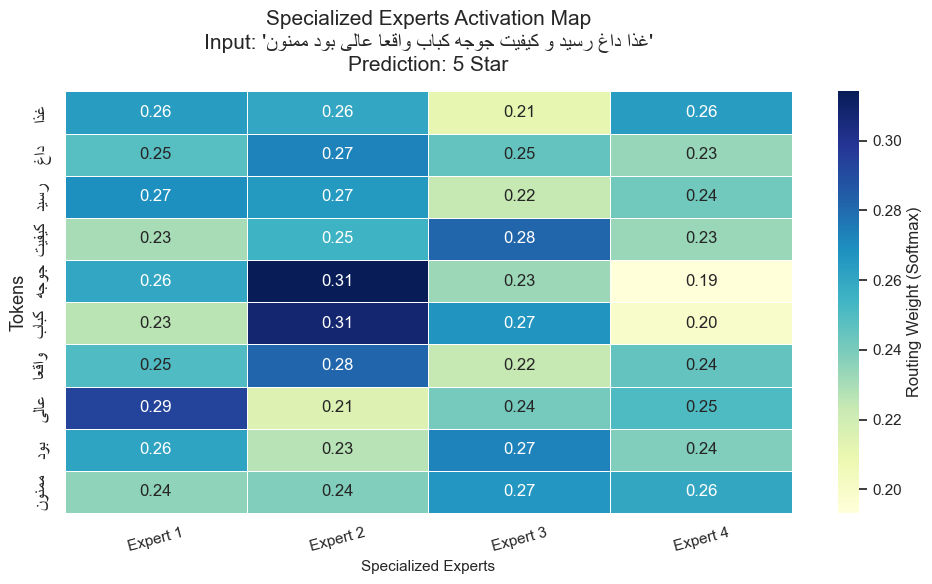

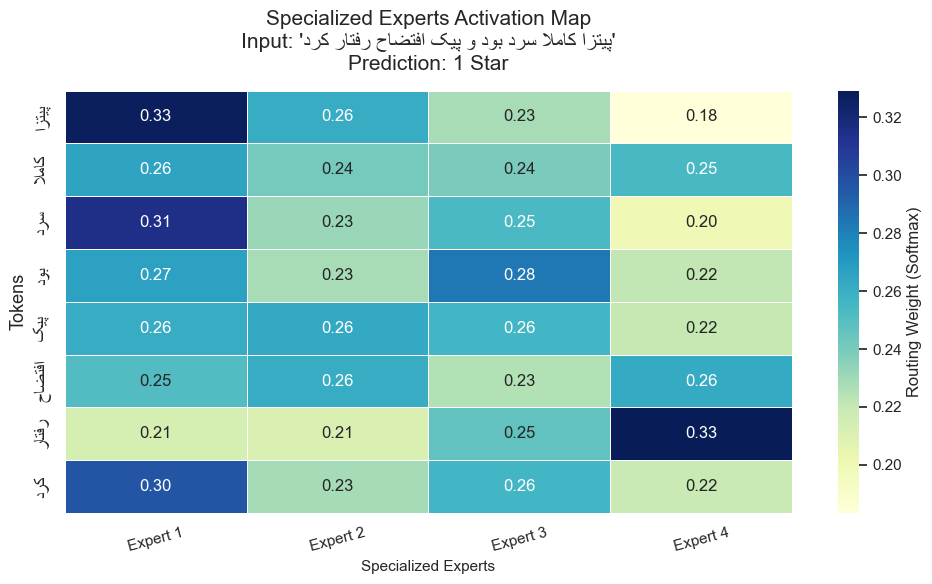

In [17]:
# 1st sample comment (obvious 5 stars)
sample_positive = "غذا داغ رسید و کیفیت جوجه کباب واقعا عالی بود ممنون"
visualize_persian_routing(model, sample_positive, snappfood_tokenizer_bridge, MAX_SEQ_LEN, device=DEVICE)

# 2nd sample comment (obvious 1 star)
sample_negative = "پیتزا کاملا سرد بود و پیک افتضاح رفتار کرد"
visualize_persian_routing(model, sample_negative, snappfood_tokenizer_bridge, MAX_SEQ_LEN, device=DEVICE)

In [18]:
def discover_expert_specialties(model, data_loader, vocab_dict, top_n=15, device='cuda'):
    model.eval()
    model.to(device)
    
    # reverce dictionery for converting id to word
    idx_to_word = {idx: word for word, idx in vocab_dict.items()}
    
    # a counter for each expert
    from collections import Counter
    expert_word_counts = {i: Counter() for i in range(model.moe.num_experts)}
    
    print("Analyzing... \n")
    
    with torch.no_grad():
        for batch_tokens, _ in data_loader:
            batch_tokens = batch_tokens.to(device)
            
            _, routing_weights, _ = model(batch_tokens, return_weights=True)
            
            best_experts = torch.argmax(routing_weights, dim=-1).cpu().numpy()
            tokens_np = batch_tokens.cpu().numpy()
            
            for b in range(tokens_np.shape[0]):
                for s in range(tokens_np.shape[1]):
                    token_id = tokens_np[b, s]
                    expert_id = int(best_experts[b, s])
                    
                    if token_id != vocab_dict.get("<PAD>") and token_id != vocab_dict.get("<UNK>"):
                        word = idx_to_word.get(token_id, "")
                        expert_word_counts[expert_id][word] += 1
                        

    for i in range(model.moe.num_experts):
        print(f"Expert {i+1} (Most commen word for this expert):")
        top_words = expert_word_counts[i].most_common(top_n)
        words_list = [f"{w} ({c} times)" for w, c in top_words]
        print(" | ".join(words_list))
        print("-" * 60)

discover_expert_specialties(model, val_loader, vocab, top_n=5, device=DEVICE)

Analyzing... 

Expert 1 (Most commen word for this expert):
عالی (1406 times) | خیلی (636 times) | مثل (591 times) | بود (427 times) | شیلا (337 times)
------------------------------------------------------------
Expert 2 (Most commen word for this expert):
رسید (391 times) | خوب (379 times) | همیشه (366 times) | خوشمزه (359 times) | واقعا (247 times)
------------------------------------------------------------
Expert 3 (Most commen word for this expert):
بود (1815 times) | خوب (437 times) | کیفیت (421 times) | عالی (284 times) | خوشمزه (228 times)
------------------------------------------------------------
Expert 4 (Most commen word for this expert):
بود (577 times) | همیشه (519 times) | غذا (459 times) | کیفیت (456 times) | عالی (394 times)
------------------------------------------------------------


In [19]:
test_dataset = SnappFoodDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
val_preds, val_targets = [], []
with torch.no_grad():
    for tokens, labels in val_loader:
        tokens = tokens.to(DEVICE)
        logits, _ = model(tokens)
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        val_preds.extend(preds)
        val_targets.extend(labels.numpy())

from sklearn.metrics import classification_report
print("Validation Report:")
print(classification_report(val_targets, val_preds, target_names=['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']))

test_preds, test_targets = [], []
with torch.no_grad():
    for tokens, labels in test_loader:
        tokens = tokens.to(DEVICE)
        logits, _ = model(tokens)
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        test_preds.extend(preds)
        test_targets.extend(labels.numpy())

print("Test Report:")
print(classification_report(test_targets, test_preds, target_names=['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']))

Validation Report:
              precision    recall  f1-score   support

      1 Star       0.47      0.46      0.47       177
     2 Stars       0.17      0.46      0.24       103
     3 Stars       0.28      0.37      0.32       233
     4 Stars       0.26      0.41      0.31       449
     5 Stars       0.97      0.84      0.90      3873

    accuracy                           0.75      4835
   macro avg       0.43      0.51      0.45      4835
weighted avg       0.83      0.75      0.79      4835

Test Report:
              precision    recall  f1-score   support

      1 Star       0.48      0.52      0.50       176
     2 Stars       0.15      0.37      0.21       102
     3 Stars       0.28      0.37      0.32       234
     4 Stars       0.26      0.44      0.33       450
     5 Stars       0.97      0.83      0.89      3873

    accuracy                           0.75      4835
   macro avg       0.43      0.51      0.45      4835
weighted avg       0.83      0.75      0.79  

In [20]:
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

torch.save(model.state_dict(), 'moe_model.pth')

class DenseTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, d_hidden, max_seq_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_seq_len, d_model)
        self.attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=8, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_model),
            nn.Dropout(0.1)
        )
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)
        self.fc_out = nn.Linear(d_model, 5)

    def forward(self, text_tokens):
        B, S = text_tokens.shape
        positions = torch.arange(0, S, device=text_tokens.device).unsqueeze(0).expand(B, S)
        pad_mask = (text_tokens == 0)
        x = self.embedding(text_tokens) + self.pos_embedding(positions)
        attn_out, _ = self.attention(x, x, x, key_padding_mask=pad_mask)
        x = self.layer_norm1(x + attn_out)
        ffn_out = self.ffn(x)
        x = self.layer_norm2(x + ffn_out)
        mask_expanded = (~pad_mask).unsqueeze(-1).float()
        x_pooled = (x * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1.0)
        return self.fc_out(x_pooled)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, d_hidden):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.lstm = nn.LSTM(d_model, d_hidden, batch_first=True, bidirectional=True)
        self.fc_out = nn.Linear(d_hidden * 2, 5)

    def forward(self, text_tokens):
        pad_mask = (text_tokens == 0)
        x = self.embedding(text_tokens)
        out, _ = self.lstm(x)
        mask_expanded = (~pad_mask).unsqueeze(-1).float()
        h_pool = (out * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1.0)
        return self.fc_out(h_pool)

dense_model = DenseTransformerClassifier(VOCAB_SIZE, D_MODEL, D_HIDDEN, MAX_SEQ_LEN).to(DEVICE)
dense_optimizer = torch.optim.AdamW(dense_model.parameters(), lr=1e-3, weight_decay=0.01)

bilstm_model = BiLSTMClassifier(VOCAB_SIZE, D_MODEL, D_HIDDEN).to(DEVICE)
bilstm_optimizer = torch.optim.AdamW(bilstm_model.parameters(), lr=1e-3, weight_decay=0.01)

for epoch in range(5):
    dense_model.train()
    for b_tokens, b_labels in train_loader:
        b_tokens, b_labels = b_tokens.to(DEVICE), b_labels.to(DEVICE)
        dense_optimizer.zero_grad()
        out = dense_model(b_tokens)
        loss = criterion(out, b_labels)
        loss.backward()
        dense_optimizer.step()

for epoch in range(5):
    bilstm_model.train()
    for b_tokens, b_labels in train_loader:
        b_tokens, b_labels = b_tokens.to(DEVICE), b_labels.to(DEVICE)
        bilstm_optimizer.zero_grad()
        out = bilstm_model(b_tokens)
        loss = criterion(out, b_labels)
        loss.backward()
        bilstm_optimizer.step()

dense_model.eval()
b_preds, b_targets = [], []
with torch.no_grad():
    for tokens, labels in test_loader:
        tokens = tokens.to(DEVICE)
        out = dense_model(tokens)
        preds = torch.argmax(out, dim=-1).cpu().numpy()
        b_preds.extend(preds)
        b_targets.extend(labels.numpy())

print("Dense Transformer Baseline Test Report:")
print(classification_report(b_targets, b_preds, target_names=['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']))

bilstm_model.eval()
l_preds, l_targets = [], []
with torch.no_grad():
    for tokens, labels in test_loader:
        tokens = tokens.to(DEVICE)
        out = bilstm_model(tokens)
        preds = torch.argmax(out, dim=-1).cpu().numpy()
        l_preds.extend(preds)
        l_targets.extend(labels.numpy())

print("BiLSTM Baseline Test Report:")
print(classification_report(l_targets, l_preds, target_names=['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']))

Dense Transformer Baseline Test Report:
              precision    recall  f1-score   support

      1 Star       0.33      0.53      0.41       176
     2 Stars       0.12      0.26      0.16       102
     3 Stars       0.23      0.49      0.31       234
     4 Stars       0.29      0.34      0.31       450
     5 Stars       0.97      0.82      0.89      3873

    accuracy                           0.74      4835
   macro avg       0.39      0.49      0.42      4835
weighted avg       0.83      0.74      0.77      4835

BiLSTM Baseline Test Report:
              precision    recall  f1-score   support

      1 Star       0.46      0.47      0.46       176
     2 Stars       0.15      0.27      0.20       102
     3 Stars       0.27      0.47      0.34       234
     4 Stars       0.26      0.51      0.34       450
     5 Stars       0.97      0.79      0.87      3873

    accuracy                           0.73      4835
   macro avg       0.42      0.50      0.44      4835
weighted

In [21]:
import torch
from fvcore.nn import FlopCountAnalysis, flop_count_table

# Create a dummy input (Batch Size = 1, Sequence Length = MAX_SEQ_LEN)
dummy_input = torch.randint(0, VOCAB_SIZE, (1, MAX_SEQ_LEN)).to(DEVICE)

print("Analyzing FLOPs... This might take a few seconds.\n")
print("="*50)

# 1. FLOPs for Sparse MoE Model
model.eval()
moe_flops = FlopCountAnalysis(model, dummy_input)
moe_total = moe_flops.total()

print("=== Sparse MoE Text Classifier ===")
# flop_count_table generates a detailed breakdown perfect for paper tables
print(flop_count_table(moe_flops))
print(f"Total FLOPs (MoE): {moe_total:,}\n")

print("="*50)

# 2. FLOPs for Dense Transformer Baseline
dense_model.eval()
dense_flops = FlopCountAnalysis(dense_model, dummy_input)
dense_total = dense_flops.total()

print("=== Dense Transformer Baseline ===")
print(flop_count_table(dense_flops))
print(f"Total FLOPs (Dense): {dense_total:,}\n")

print("="*50)

# 3. Final Comparison
savings = (1 - (moe_total / dense_total)) * 100
print(f"Hardware Efficiency: MoE model requires {savings:.2f}% fewer FLOPs per inference compared to the Dense model.")

Unsupported operator aten::embedding encountered 2 time(s)
Unsupported operator aten::add encountered 4 time(s)
Unsupported operator aten::masked_fill_ encountered 1 time(s)
Unsupported operator aten::div encountered 3 time(s)
Unsupported operator aten::unflatten encountered 1 time(s)
Unsupported operator aten::mul encountered 14 time(s)
Unsupported operator aten::baddbmm encountered 1 time(s)


Analyzing FLOPs... This might take a few seconds.



Unsupported operator aten::softmax encountered 2 time(s)
Unsupported operator aten::topk encountered 1 time(s)
Unsupported operator aten::sum encountered 4 time(s)
Unsupported operator aten::mean encountered 2 time(s)
Unsupported operator aten::one_hot encountered 1 time(s)
Unsupported operator aten::any encountered 4 time(s)
Unsupported operator aten::nonzero_numpy encountered 4 time(s)
Unsupported operator aten::add_ encountered 4 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
attention.out_proj
Unsupported operator aten::embedding encountered 2 time(s)
Unsupported operator aten::add encountered 3 time(s)
Unsupported operator aten::masked_fill_ encountered 1 time(s)
Unsupported operator aten::div encounter

=== Sparse MoE Text Classifier ===
| module                    | #parameters or shape   | #flops   |
|:--------------------------|:-----------------------|:---------|
| model                     | 1.194M                 | 6.964M   |
| embedding                 | 0.856M                 | 0        |
| embedding.weight          | (6689, 128)            |          |
| pos_embedding             | 6.4K                   | 0        |
| pos_embedding.weight      | (50, 128)              |          |
| attention                 | 66.048K                | 3.597M   |
| attention.in_proj_weight  | (384, 128)             |          |
| attention.in_proj_bias    | (384,)                 |          |
| attention.out_proj        | 16.512K                |          |
| attention.out_proj.weight | (128, 128)             |          |
| attention.out_proj.bias   | (128,)                 |          |
| moe                       | 0.264M                 | 3.302M   |
| moe.experts               | 0.264M     

In [22]:
import torch

def measure_memory_footprint(model, model_name, dummy_input, device='cuda'):
    # Ensure we are tracking GPU memory
    if not torch.cuda.is_available() or device != 'cuda':
        print("Memory profiling requires an active CUDA device.")
        return
        
    model.eval()
    model.to(device)
    dummy_input = dummy_input.to(device)
    
    # Clear cache and reset stats for accurate measurement
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    
    # Perform a forward pass
    with torch.no_grad():
        _ = model(dummy_input)
        
    # Calculate peak memory in Megabytes (MB)
    peak_memory_bytes = torch.cuda.max_memory_allocated()
    peak_memory_mb = peak_memory_bytes / (1024 ** 2)
    
    print(f"{model_name} - Peak Memory (Inference): {peak_memory_mb:.2f} MB")
    return peak_memory_mb

# Defining a standardized dummy input [Batch=1, SeqLen=50]
dummy_tokens = torch.randint(0, VOCAB_SIZE, (1, MAX_SEQ_LEN)).to(DEVICE)

print("Memory Footprint Analysis:")
print("-" * 40)

# 1. MoE Memory
measure_memory_footprint(model, "Sparse MoE", dummy_tokens, DEVICE)

# 2. Dense Transformer Memory
measure_memory_footprint(dense_model, "Dense Transformer", dummy_tokens, DEVICE)

# 3. BiLSTM Memory
measure_memory_footprint(bilstm_model, "BiLSTM", dummy_tokens, DEVICE)

print("-" * 40)

Memory Footprint Analysis:
----------------------------------------
Sparse MoE - Peak Memory (Inference): 77.19 MB
Dense Transformer - Peak Memory (Inference): 76.91 MB
BiLSTM - Peak Memory (Inference): 95.71 MB
----------------------------------------
